# **Analisis Sentiment - Decision Tree**

## Preparation

### 1.1 Import Library

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import messagebox
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

### 1.2 Import Datase

In [14]:
df_before = pd.read_csv('Corpus Bahasa Indonesia Label.csv')

In [15]:
df_before['sentiment'].shape

(12609,)

In [16]:
min_count = df_before['sentiment'].value_counts().min()

df_0 = df_before[df_before['sentiment'] == 0].sample(min_count, random_state=42)
df_1 = df_before[df_before['sentiment'] == 1]
df_2 = df_before[df_before['sentiment'] == 2].sample(min_count, random_state=42)

df = pd.concat([df_0, df_1, df_2]).sample(frac=1, random_state=42).reset_index(drop=True)

In [17]:
kalimat_sentimen_1 = df[df['sentiment'] == 2]
kalimat_sentimen_1.shape

(2826, 2)

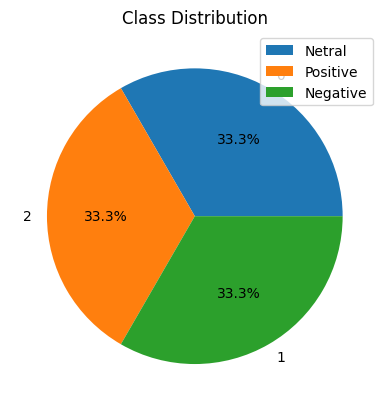

In [18]:
# Pie Chart
plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.legend(['Netral','Positive', 'Negative'])
plt.show()

### 1.3 Cek info 

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8478 entries, 0 to 8477
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   kalimat    8478 non-null   object
 1   sentiment  8478 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 132.6+ KB


### 1.4 Memprosess Teks

In [20]:
stopword = set(stopwords.words('indonesian'))
faktor = StemmerFactory()
Stemmer = faktor.create_stemmer()

def cleaning(text):
    text_bersih = text.lower() # case normalization
    text_bersih = re.sub(r'https\S+', '', text_bersih) # text cleaning
    text_bersih = re.sub(r'@[A-Za-z0-9_]+', '', text_bersih)
    text_bersih = re.sub(r'#([A-Za-z0-9_])+', '', text_bersih)
    text_bersih = re.sub(r'[^a-z\s]', '', text_bersih)
    text_bersih = re.sub(r'\d+', '', text_bersih)
    text_bersih = re.sub(r'\s+', ' ', text_bersih)
    
    text_bersih = [Stemmer.stem(word) for word in text_bersih if word not in stopword]

    return ' '.join(text_bersih)


# ts = 'woi prabowok 948291 *&*@() amb mana sawit graTISNYA wok'

# hasil = cleaning(ts)
# print(hasil)

df['pesan_bersih'] = df['kalimat'].apply(cleaning)

In [21]:
df.head()

,kalimat,sentiment,pesan_bersih
0,sepintas babah ho liang memandang disekitarnya...,0,s e p i n t a s b a b a h h o l i a n g m ...
1,bau busuk yang keluar dari mulut saya seperti ...,2,b a u b u s u k y a n g k e l u a r d a r ...
2,sulastri terpingkal-pingkal tertawanya,1,s u l a s t r i t e r p i n g k a l p i n g k...
3,Sisanya menggunakan WC umum atau memakai WC te...,0,s i s a n y a m e n g g u n a k a n w c u m...
4,menteri koordinator kemaritiman ri luhut binsa...,1,m e n t e r i k o o r d i n a t o r k e m a ...


In [22]:
# factory = StemmerFactory()
# stemmer = factory.create_stemmer()

# stop_words = set(stopwords.words('indonesian'))

# def preprocess_text(text):
#     text = text.lower()
#     text = re.sub(r'[^a-z\s]', '', text)
#     tokens = word_tokenize(text)
#     tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
#     return ' '.join(tokens)

# df['kalimat_clean'] = df['kalimat'].apply(preprocess_text)
# print(df[['kalimat', 'kalimat_clean']].head())

## 2. Modedl

### 2.1 Independent dan Dependent

In [24]:
df.head()

,kalimat,sentiment,pesan_bersih
0,sepintas babah ho liang memandang disekitarnya...,0,s e p i n t a s b a b a h h o l i a n g m ...
1,bau busuk yang keluar dari mulut saya seperti ...,2,b a u b u s u k y a n g k e l u a r d a r ...
2,sulastri terpingkal-pingkal tertawanya,1,s u l a s t r i t e r p i n g k a l p i n g k...
3,Sisanya menggunakan WC umum atau memakai WC te...,0,s i s a n y a m e n g g u n a k a n w c u m...
4,menteri koordinator kemaritiman ri luhut binsa...,1,m e n t e r i k o o r d i n a t o r k e m a ...


In [25]:
X = df['pesan_bersih']
y = df['sentiment']

### 2.2 Split Data

In [26]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(0.8 * len(idx_0))
train_1 = int(0.8 * len(idx_1))

train_idx = np.concatenate((idx_0[:train_0], idx_1[:train_1]))
test_idx = np.concatenate((idx_0[train_0:], idx_1[train_1:]))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

NameError: name 'X_train' is not defined

### 2.3 TF-IDF

In [27]:
all_words = set()
for doc in X_train:
    all_words.update(doc.split())

word_list = list(all_words)
word_to_idx = {word: idx for idx, word in enumerate(word_list)}

num_docs = len(X_train)
vocab_size = len(word_list)

# traainkl
tf_matrix = np.zeros((num_docs, vocab_size))
for i, doc in enumerate(X_train):
    words = doc.split()
    word_counts = np.bincount([word_to_idx[word] for word in words if word in word_to_idx], minlength=vocab_size)
    tf_matrix[i] = word_counts / len(words) if len(words) > 0 else 0

doc_freq = np.sum(tf_matrix > 0, axis=0)
idf = np.log(num_docs / (1 + doc_freq))

tfidf_train = tf_matrix * idf

# tes
tfidf_test = np.zeros((len(X_test), vocab_size))
for i, doc in enumerate(X_test):
    words = doc.split()
    word_counts = np.bincount([word_to_idx[word] for word in words if word in word_to_idx], minlength=vocab_size)
    tfidf_test[i] = (word_counts / len(words) if len(words) > 0 else 0) * idf

print(f'TF-IDF Train shape: {tfidf_train.shape}')
print(f'TF-IDF Test shape: {tfidf_test.shape}')

TF-IDF Train shape: (4520, 26)
TF-IDF Test shape: (1132, 26)


### 2.4 Bangun pohon

In [ ]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs ** 2)

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5):
    if len(np.unique(y)) == 1 or depth >= max_depth or len(y) < 2:
        return DecisionTreeNode(value=np.argmax(np.bincount(y)))
    
    num_features = X.shape[1]
    best_gini = float('inf')
    best_feature = None
    best_threshold = None
    
    for feature in range(num_features):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold
            if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                continue
            gini_left = gini_impurity(y[left_idx])
            gini_right = gini_impurity(y[right_idx])
            weighted_gini = (len(y[left_idx]) * gini_left + len(y[right_idx]) * gini_right) / len(y)
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature
                best_threshold = threshold
    
    if best_feature is None:
        return DecisionTreeNode(value=np.argmax(np.bincount(y)))
    
    left_idx = X[:, best_feature] <= best_threshold
    right_idx = X[:, best_feature] > best_threshold
    left = build_tree(X[left_idx], y[left_idx], depth + 1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth + 1, max_depth)
    
    return DecisionTreeNode(feature=best_feature, threshold=best_threshold, left=left, right=right)


### 2.5 Prediksi

In [ ]:
def predict_tree(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

y_pred_test = np.array([predict_tree(tree, row) for row in tfidf_test])
y_pred_train = np.array([predict_tree(tree, row) for row in tfidf_train])



NameError: name 'tree' is not defined

In [ ]:
def predict(node, sample):
    if node.value is not None:
        return node.value
    if sample[node.feature] <= node.threshold:
        return predict(node.left, sample)
    else:
        return predict(node.right, sample)
    
def predict_batch(node, X):
    return np.array([predict(node, sample) for sample in X])

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [ ]:
def grid_search_max_depth(X_train, y_train, X_test, y_test, depths):
    best_depth = None
    best_acc = 0
    accuracies = []
    
    for depth in depths:
        tree = build_tree(X_train, y_train, max_depth=depth)
        y_pred = predict_batch(tree, X_test)
        acc = accuracy(y_test, y_pred)
        accuracies.append(acc)
        print(f"Max Depth: {depth}, Accuracy: {acc}")
        if acc > best_acc:
            best_acc = acc
            best_depth = depth
    
    return best_depth, accuracies

depths = range(1, 11)
best_depth, accuracies = grid_search_max_depth(tfidf_train, y_train, tfidf_test, y_test, depths)

print(f"\nBest Max Depth: {best_depth}")

Max Depth: 1, Accuracy: 0.5167844522968198
Max Depth: 2, Accuracy: 0.5167844522968198
Max Depth: 3, Accuracy: 0.5291519434628975
Max Depth: 4, Accuracy: 0.5291519434628975
Max Depth: 5, Accuracy: 0.519434628975265
Max Depth: 6, Accuracy: 0.5335689045936396
Max Depth: 7, Accuracy: 0.5282685512367491
Max Depth: 8, Accuracy: 0.5397526501766784
Max Depth: 9, Accuracy: 0.5353356890459364
Max Depth: 10, Accuracy: 0.5485865724381626

Best Max Depth: 10


In [ ]:
tree = build_tree(tfidf_train, y_train, max_depth=best_depth)


In [ ]:
def predict_tree(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

y_pred_test = np.array([predict_tree(tree, row) for row in tfidf_test])
y_pred_train = np.array([predict_tree(tree, row) for row in tfidf_train])



In [ ]:
y_pred_final = predict_batch(tree, tfidf_train)

## 3. Evaluasi

In [ ]:
classes = [0, 1, 2]
conf_matrix = np.zeros((3, 3), dtype=int)
for true, pred in zip(y_test, y_pred_test):
    conf_matrix[true, pred] += 1

def evalua(y_true, y_pred, classes):
    report = {}
    for cls in classes:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        report[cls] = {'precision': precision, 'recall': recall, 'f1': f1}
    return report

report = evalua(y_test, y_pred_test, [0,1,2])
accuracy_test = np.mean(y_pred_test == y_test)
accuracy_train = np.mean(y_pred_train == y_train)
print(f'Akurasi test: {accuracy_test * 100:.2f}%')
print(f'Akurasi train: {accuracy_train * 100:.2f}%')
print(report)

Akurasi test: 71.71%
Akurasi train: 72.05%
{0: {'precision': np.float64(0.7141261864879955), 'recall': np.float64(0.9891724671307038), 'f1': np.float64(0.8294422827496758)}, 1: {'precision': np.float64(0.7941176470588235), 'recall': np.float64(0.09540636042402827), 'f1': np.float64(0.17034700315457413)}, 2: {'precision': 0, 'recall': 0, 'f1': 0}}


## 4. ~~Graphical User Interface~~ Tes Model

In [ ]:
def predict_sentiment(text, tree, word_to_idx, idf):
    cleaned_text = preprocess_text(text)
    words = cleaned_text.split()
    
    vocab_size = len(word_to_idx)
    tf_vector = np.zeros(vocab_size)
    if words:
        word_indices = [word_to_idx[word] for word in words if word in word_to_idx]
        word_counts = np.bincount(word_indices, minlength=vocab_size)
        tf_vector = word_counts / len(words)
    
    tfidf_vector = tf_vector * idf
    
    prediction = predict_tree(tree, tfidf_vector)
    
    sentiment_map = {0: 'Netral', 1: 'Positif', 2: 'Negatif'}
    return prediction

In [ ]:
ex = "indonesia maju hebat"
hasil = predict_sentiment(ex, tree, word_to_idx, idf)
print(f"{ex} \nhasilnya: {hasil}")

indonesia maju hebat 
hasilnya: 0


In [ ]:
kalimat_sentimen_2 = df[df['sentiment'] == 0]
print(kalimat_sentimen_2)

                                                 kalimat  sentiment  \
0        Kalimat-kalimat tersebut adalah sebagai berikut          0   
2      Tanaman hijau menggunakan air untuk membuat ma...          0   
6      Tabel 5.2 memperlihatkan hubungan antara hasil...          0   
9      Tabel 5.3 memperlihatkan lebih jauh pentingnya...          0   
10     Masa kerja guru mempunyai korelasi positif den...          0   
...                                                  ...        ...   
12586    Saya merasa puas dengan performa kendaraan ini.          0   
12589  Saya memilih kendaraan ini karena modelnya ele...          0   
12594  Kendaraan tersebut memiliki fitur keselamatan ...          0   
12598  Saya memilih kendaraan ini karena hemat bahan ...          0   
12601   Saya merasa aman saat menggunakan kendaraan ini.          0   

                                           kalimat_clean  
0                                         kalimatkalimat  
2                            

In [ ]:
kalimat_sentimen_1 = df[df['sentiment'] == 1]
print(kalimat_sentimen_1)

                                                 kalimat  sentiment  \
1      Manusia membutuhkan makanan dan air supaya men...          1   
3      Tanaman yang tidak mendapat air akan layu dan ...          1   
4      Keberhasilan belajar murid tidak hanya bergant...          1   
11     tetapi sampai batas tertentu, yaitu dengan ras...          1   
19     Persoalan ini perlu dipelajari lebih lanjut, k...          1   
...                                                  ...        ...   
12600  Kendaraan tersebut tidak memiliki sistem hiburan.          1   
12602   Kendaraan ini memiliki fitur canggih dan modern.          1   
12604  Saya suka menggunakan kendaraan ini untuk perj...          1   
12605  Kendaraan ini memiliki desain interior yang me...          1   
12607  Saya memilih kendaraan ini karena harganya kom...          1   

                                          kalimat_clean  
1              manusia butuh makan air kuat sehat tanam  
3                              